Initial exploratory data analysis

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
runs = pd.read_csv('../data/runs.csv')
races = pd.read_csv('../data/races.csv')

In [3]:
df = runs.merge(races, on = "race_id", how = "left", validate = "many_to_one")

In [4]:
# make a copy to make sure we keep the raw data

df_copy = df.copy()

In [5]:
df.columns.tolist()

['race_id',
 'horse_no',
 'horse_id',
 'result',
 'won',
 'lengths_behind',
 'horse_age',
 'horse_country',
 'horse_type',
 'horse_rating',
 'horse_gear',
 'declared_weight',
 'actual_weight',
 'draw',
 'position_sec1',
 'position_sec2',
 'position_sec3',
 'position_sec4',
 'position_sec5',
 'position_sec6',
 'behind_sec1',
 'behind_sec2',
 'behind_sec3',
 'behind_sec4',
 'behind_sec5',
 'behind_sec6',
 'time1_x',
 'time2_x',
 'time3_x',
 'time4_x',
 'time5_x',
 'time6_x',
 'finish_time',
 'win_odds',
 'place_odds',
 'trainer_id',
 'jockey_id',
 'date',
 'venue',
 'race_no',
 'config',
 'surface',
 'distance',
 'going',
 'horse_ratings',
 'prize',
 'race_class',
 'sec_time1',
 'sec_time2',
 'sec_time3',
 'sec_time4',
 'sec_time5',
 'sec_time6',
 'sec_time7',
 'time1_y',
 'time2_y',
 'time3_y',
 'time4_y',
 'time5_y',
 'time6_y',
 'time7',
 'place_combination1',
 'place_combination2',
 'place_combination3',
 'place_combination4',
 'place_dividend1',
 'place_dividend2',
 'place_dividend3

In [6]:
# look at distribution of data, class imbalance, any correlations etc



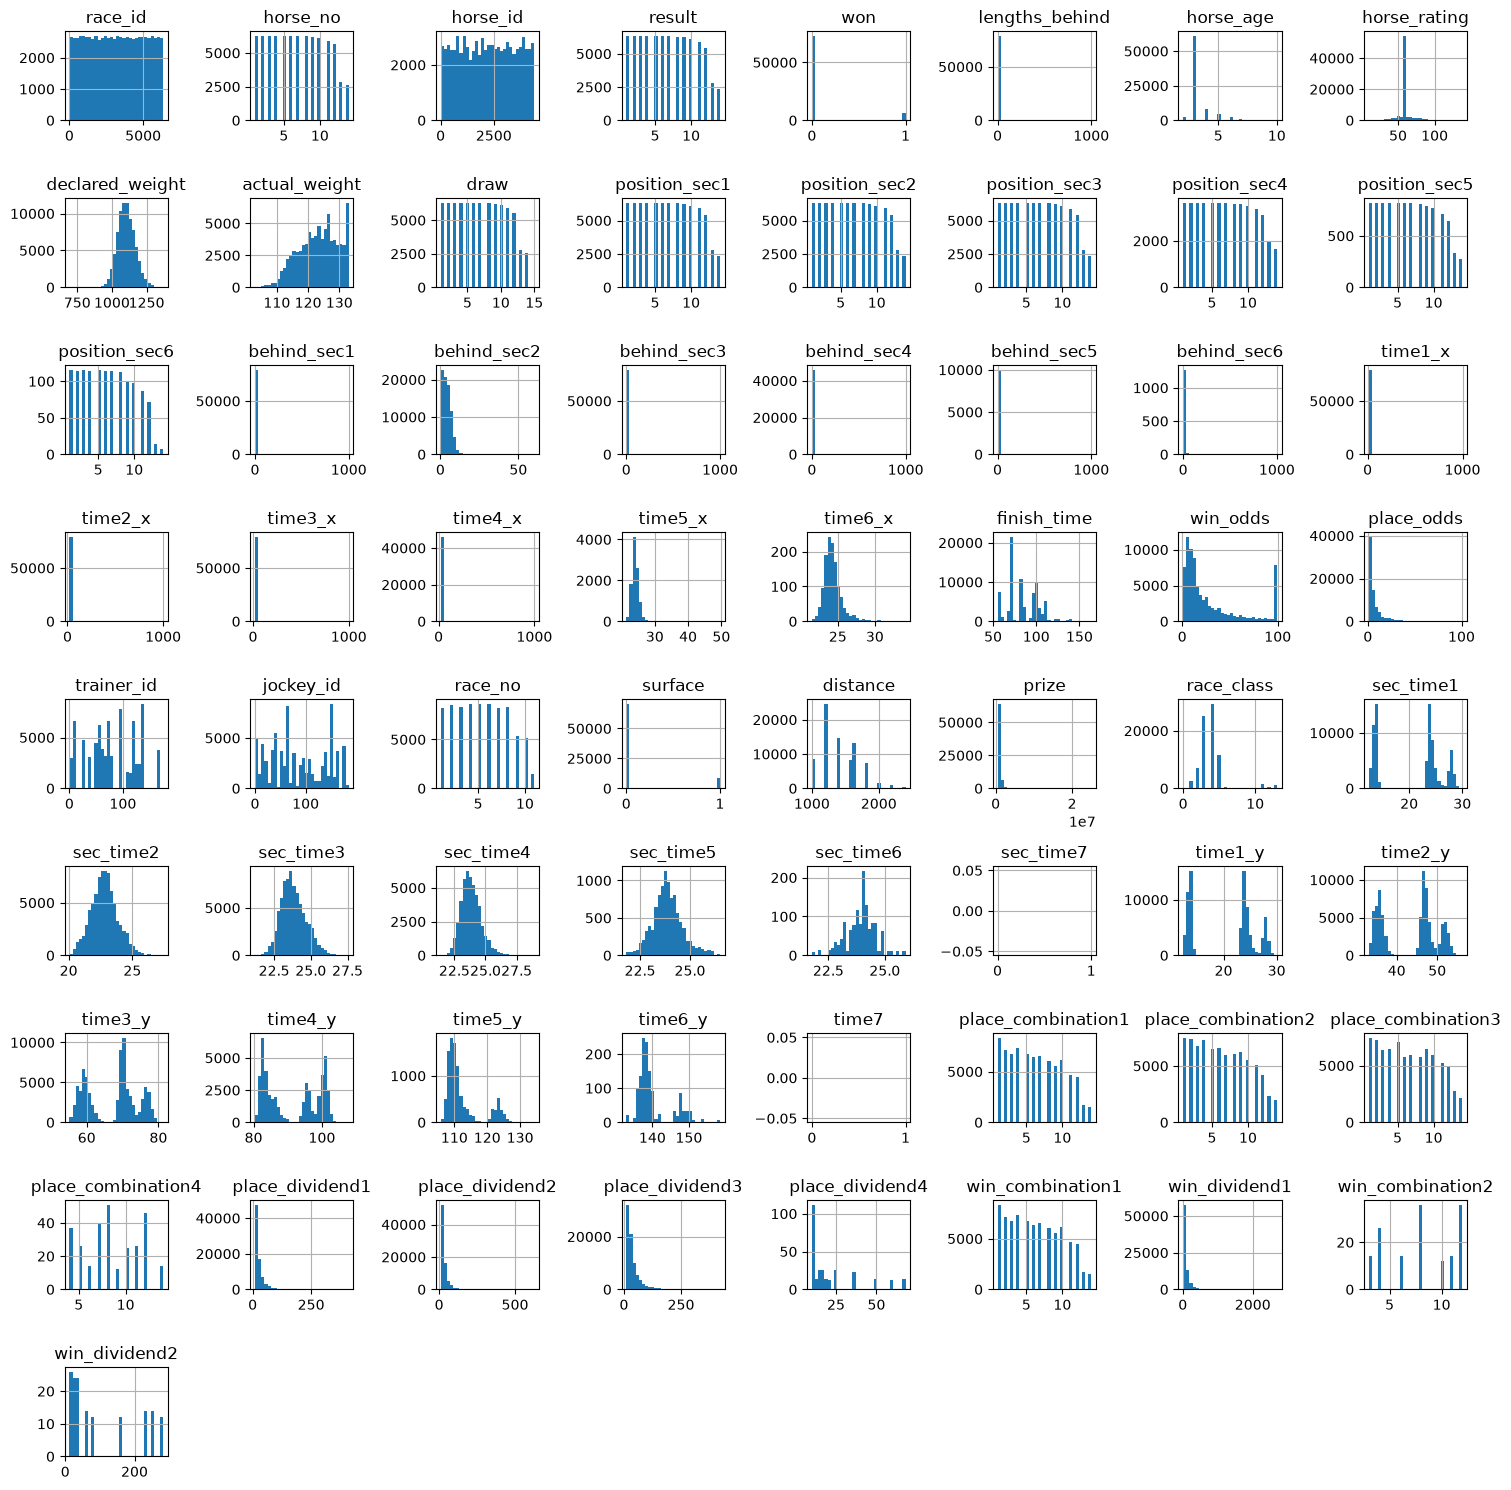

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(15, 15),
    bins=30
)

plt.tight_layout()
plt.show()

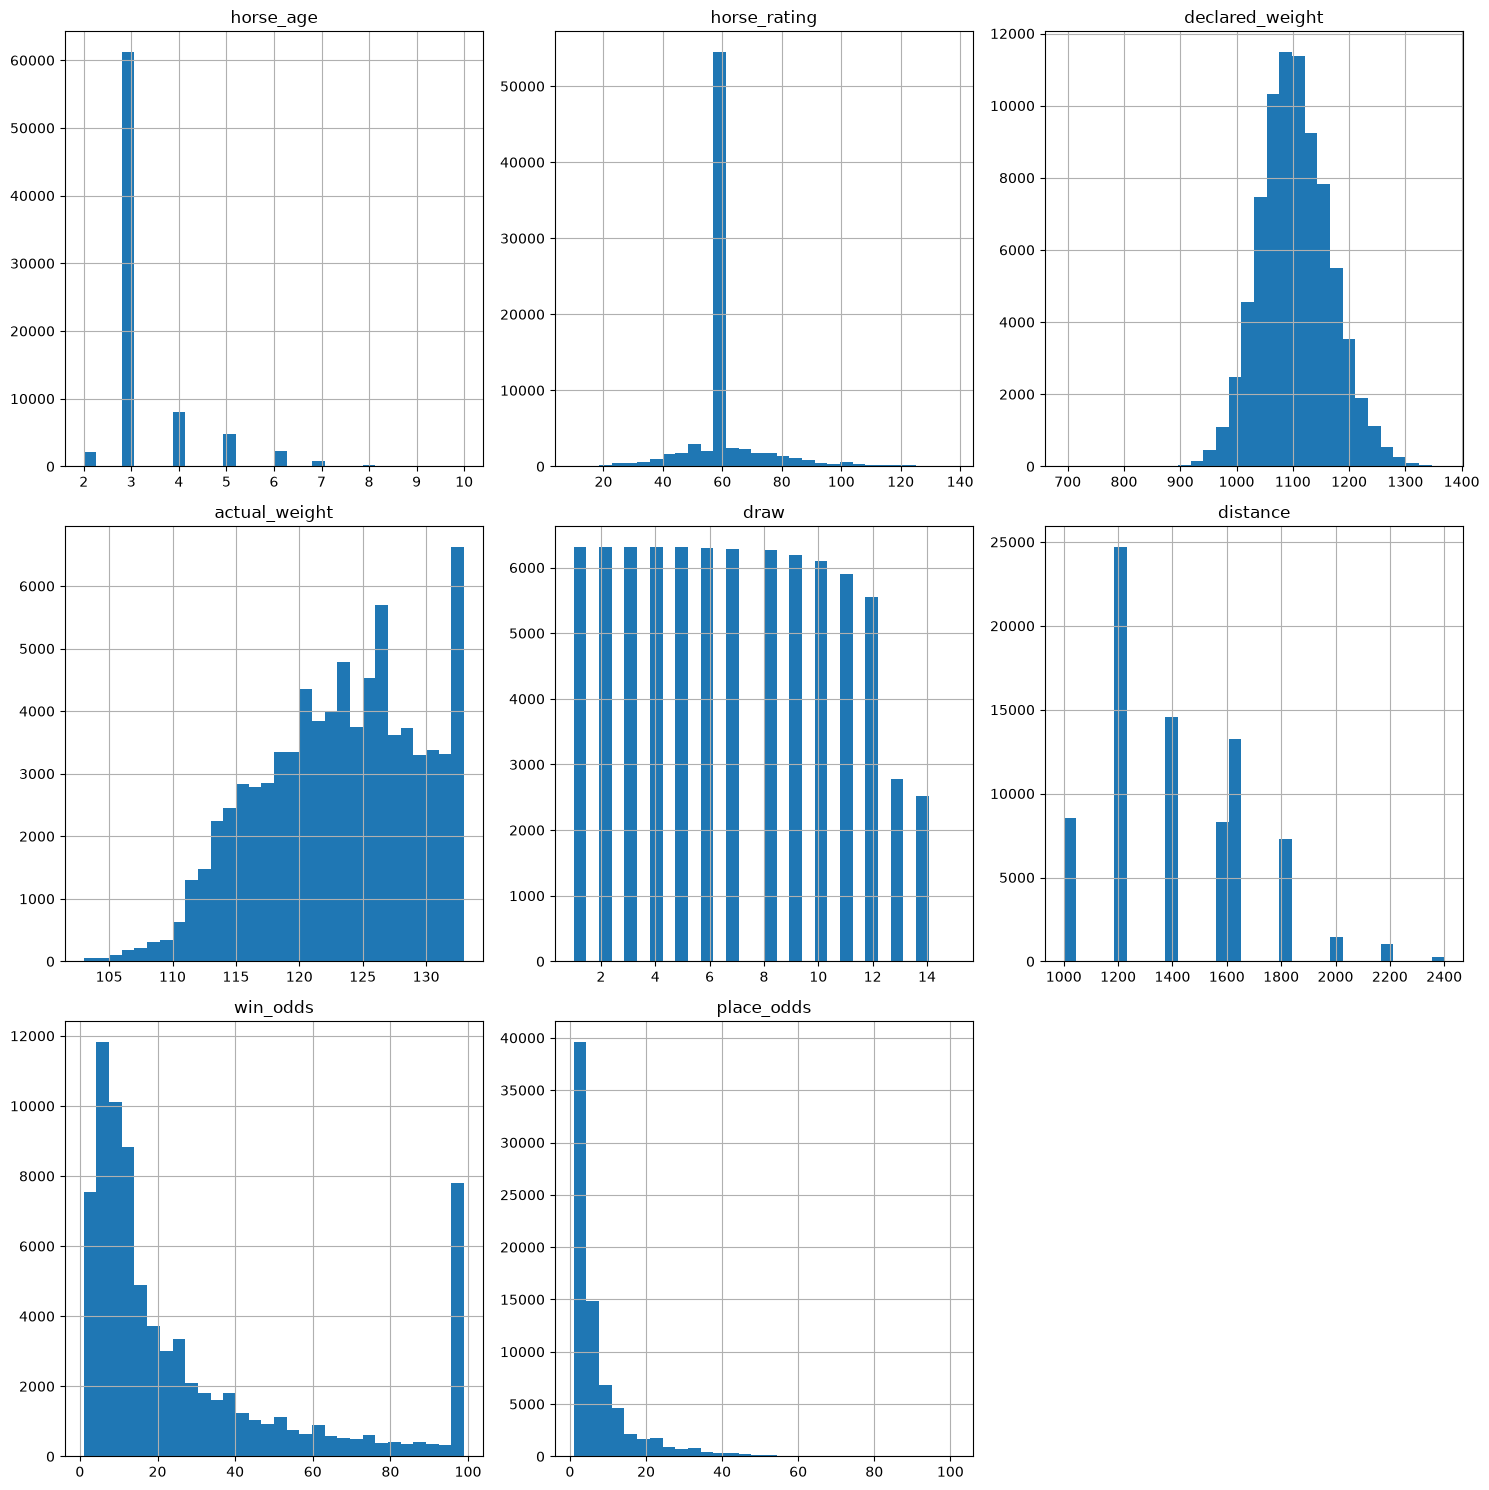

In [8]:
initial_features = [
    "horse_age",
    "horse_rating",
    "declared_weight",
    "actual_weight",
    "draw",
    "distance",
    "win_odds",
    "place_odds"
]

df[initial_features].hist(
    figsize=(15, 15),
    bins=30
)

plt.tight_layout()
plt.show()

In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df.sort_values(['date', 'horse_id'])

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,place_combination3,place_combination4,place_dividend1,place_dividend2,place_dividend3,place_dividend4,win_combination1,win_dividend1,win_combination2,win_dividend2
54,4,1,82,3,0.0,0.50,3,NZ,Gelding,60,...,1.0,NaN,15.5,28.0,17.5,NaN,2,36.5,NaN,NaN
55,4,2,97,1,1.0,0.00,3,AUS,Gelding,60,...,1.0,NaN,15.5,28.0,17.5,NaN,2,36.5,NaN,NaN
34,2,7,133,11,0.0,4.25,3,NZ,Gelding,60,...,13.0,NaN,23.0,23.0,59.5,NaN,11,70.0,NaN,NaN
59,4,6,134,12,0.0,8.25,3,AUS,Gelding,60,...,1.0,NaN,15.5,28.0,17.5,NaN,2,36.5,NaN,NaN
61,4,8,243,7,0.0,4.50,3,NZ,Brown,60,...,1.0,NaN,15.5,28.0,17.5,NaN,2,36.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79351,6341,10,4266,12,0.0,7.00,4,NZ,Gelding,65,...,5.0,NaN,16.5,10.5,23.5,NaN,3,49.5,NaN,NaN
79409,6346,3,4300,8,0.0,5.50,6,IRE,Gelding,128,...,5.0,NaN,11.0,27.5,38.5,NaN,2,17.5,NaN,NaN
79428,6347,10,4355,12,0.0,9.25,4,AUS,Gelding,85,...,4.0,NaN,11.0,37.0,21.5,NaN,9,16.0,NaN,NaN
79389,6344,7,4362,2,0.0,0.15,3,AUS,Gelding,104,...,5.0,NaN,13.5,14.5,62.5,NaN,6,38.0,NaN,NaN


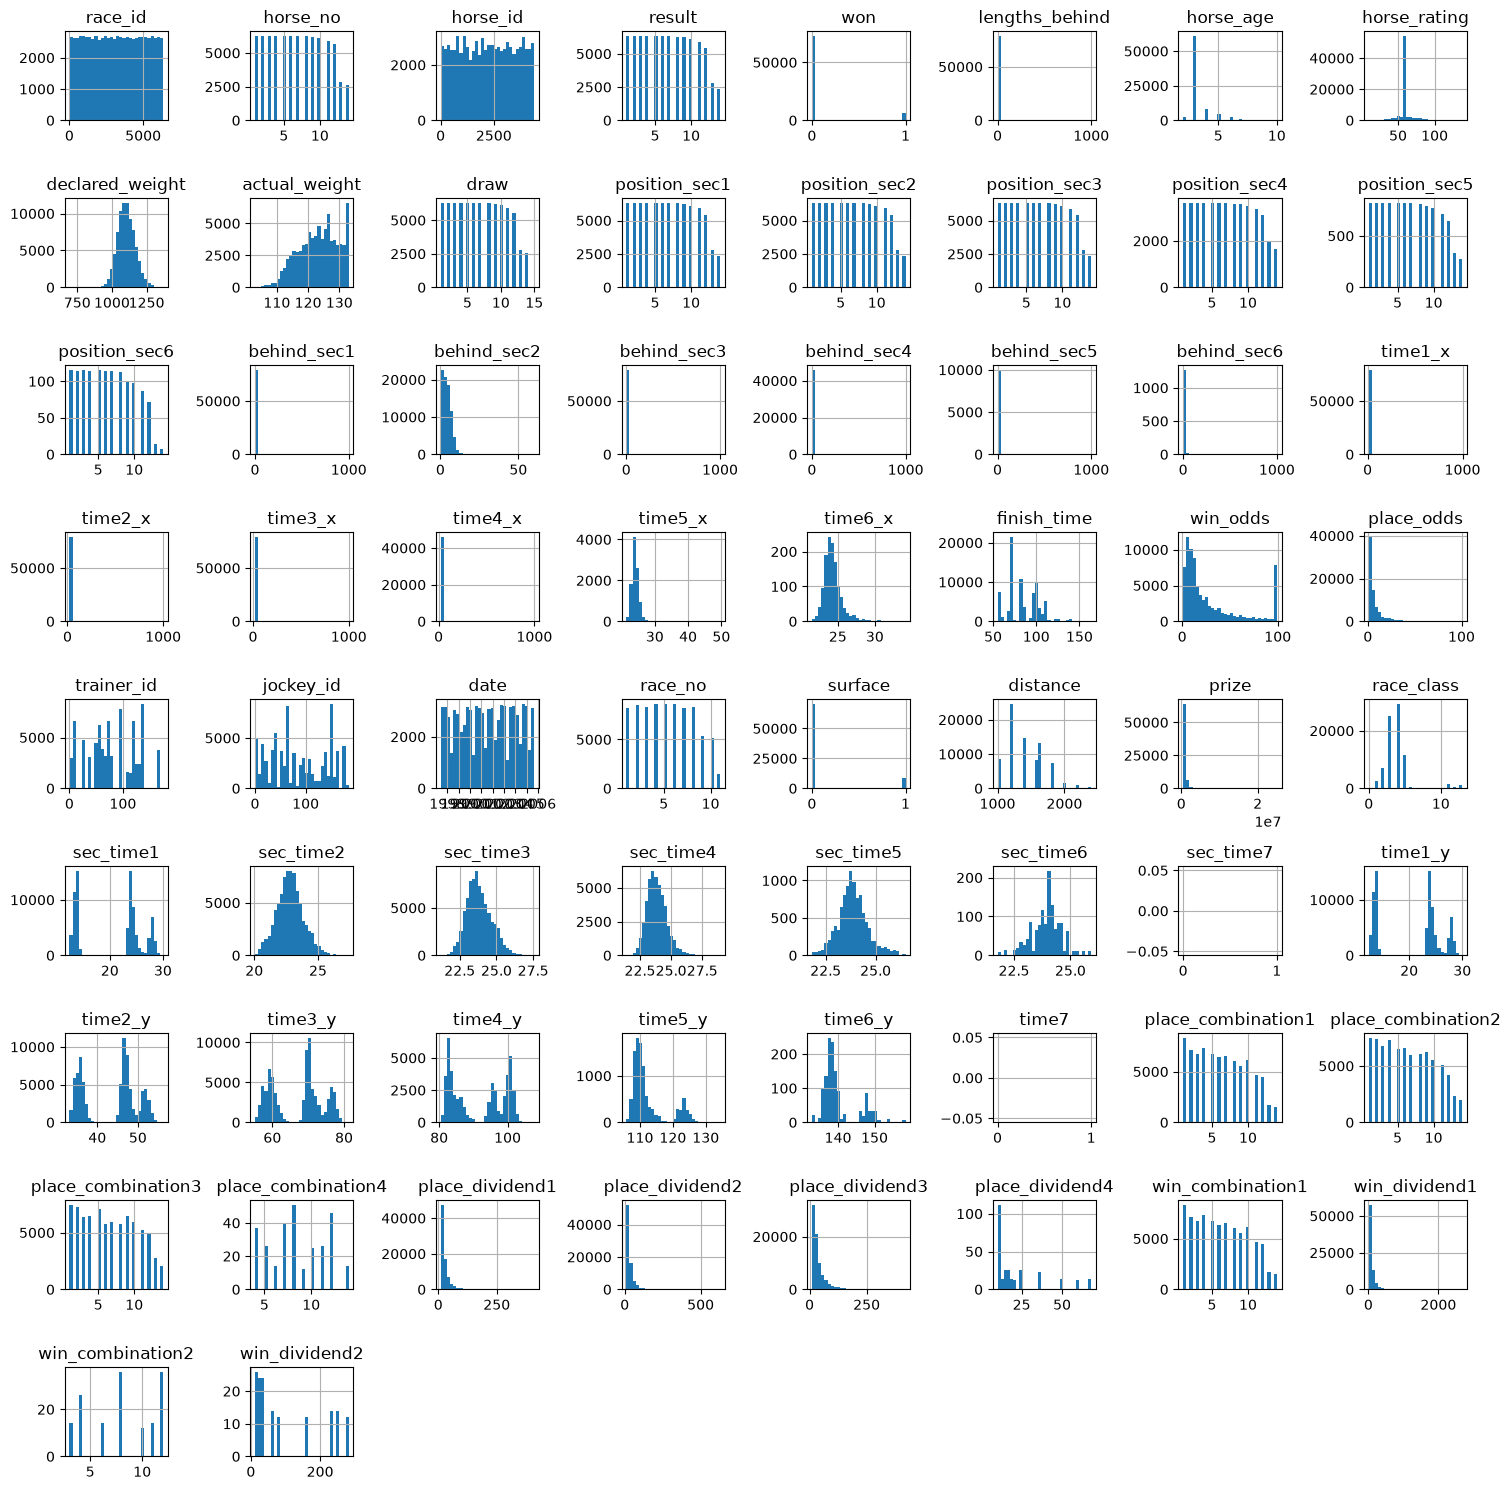

In [11]:
df.hist(
    figsize=(15, 15),
    bins=30
)

plt.tight_layout()
plt.show()

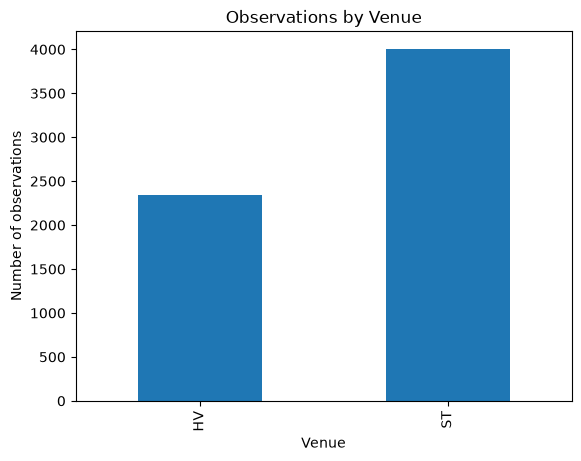

In [12]:
df.groupby('venue')['race_id'].nunique().plot(kind ='bar')


plt.xlabel("Venue")
plt.ylabel("Number of observations")
plt.title("Observations by Venue")
plt.show()

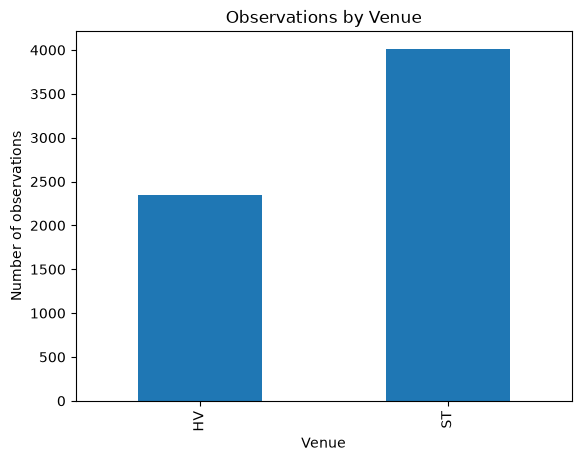

In [13]:
df.groupby('venue')['won'].sum().plot(kind ='bar')


plt.xlabel("Venue")
plt.ylabel("Number of observations")
plt.title("Observations by Venue")
plt.show()

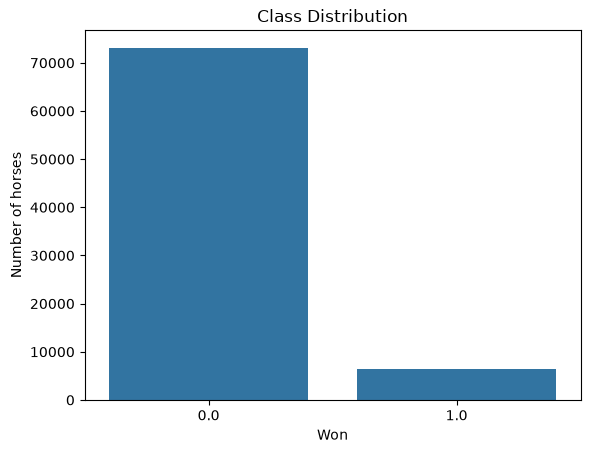

In [14]:
sns.countplot(data=df, x="won")

plt.xlabel("Won")
plt.ylabel("Number of horses")
plt.title("Class Distribution")
plt.show()

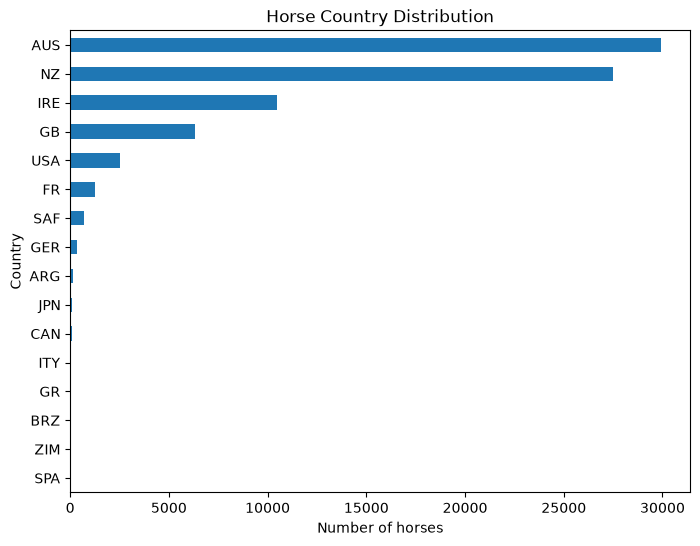

In [15]:
df["horse_country"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Number of horses")
plt.ylabel("Country")
plt.title("Horse Country Distribution")
plt.show()

In [16]:
going_stats = (
    df.groupby("going")["won"]
      .agg(["count", "mean"])
      .rename(columns={"mean": "win_rate"})
)

going_stats["win_rate"] *= 100

going_stats

,count,win_rate
going,,
FAST,878,7.972665
GOOD,51389,8.032847
GOOD TO FIRM,20410,7.927487
GOOD TO YIELDING,4131,8.061002
SLOW,187,8.021390
SOFT,175,8.000000
WET FAST,247,8.097166
WET SLOW,771,7.911803
YIELDING,1082,8.040665


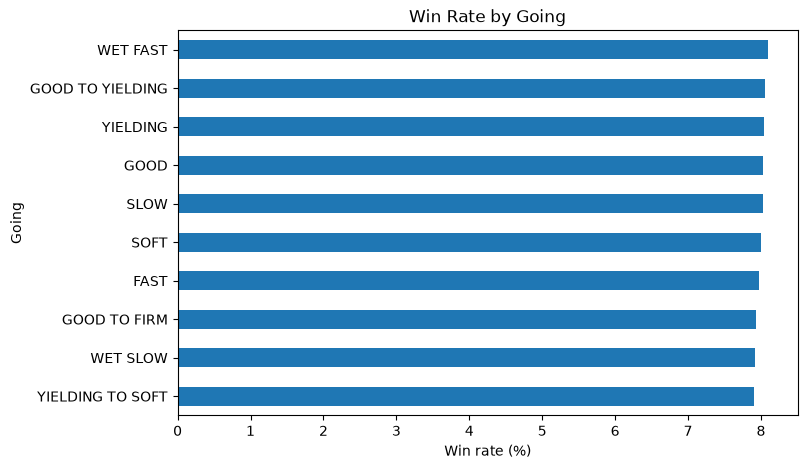

In [17]:
going_stats["win_rate"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Win rate (%)")
plt.ylabel("Going")
plt.title("Win Rate by Going")
plt.show()

In [18]:
categorical_cols = [
    "venue",
    "config",
    "surface",
    "going",
    "horse_sex",
    "horse_country",
]

In [19]:
df['surface'].value_counts(normalize=True)

surface
0    0.891135
1    0.108865
Name: proportion, dtype: float64

In [20]:
df.groupby("going")["won"].agg(["count", "mean"])

,count,mean
going,,
FAST,878,0.079727
GOOD,51389,0.080328
GOOD TO FIRM,20410,0.079275
GOOD TO YIELDING,4131,0.080610
SLOW,187,0.080214
SOFT,175,0.080000
WET FAST,247,0.080972
WET SLOW,771,0.079118
YIELDING,1082,0.080407


In [21]:
df["horse_prior_runs"] = (
    df.groupby("horse_id").cumcount()
)

df["horse_prior_wins"] = (
    df.groupby("horse_id")["won"]
      .transform(lambda x: x.shift().cumsum())
)

df["horse_prior_win_rate"] = (
    df["horse_prior_wins"] / df["horse_prior_runs"]
)

In [22]:
df["jockey_prior_runs"] = (
    df.groupby("jockey_id").cumcount()
)

df["jockey_prior_wins"] = (
    df.groupby("jockey_id")["won"]
      .transform(lambda x: x.shift().cumsum())
)

df["jockey_prior_win_rate"] = (
    df["jockey_prior_wins"] / df["jockey_prior_runs"]
)

In [23]:
df["trainer_prior_runs"] = (
    df.groupby("trainer_id").cumcount()
)

df["trainer_prior_wins"] = (
    df.groupby("trainer_id")["won"]
      .transform(lambda x: x.shift().cumsum())
)

df["trainer_prior_win_rate"] = (
    df["trainer_prior_wins"] / df["trainer_prior_runs"]
)

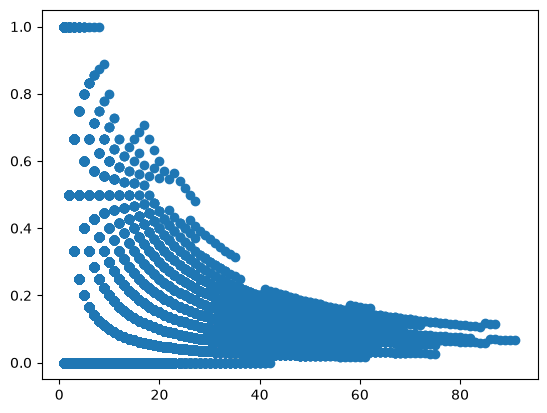

In [24]:
plt.scatter(
    x = df["horse_prior_runs"],
    y =df["horse_prior_win_rate"],
)

In [25]:
#df.drop(['sec_time7', 'time7'], axis = 1, inplace = True)
df.drop(['time2_y','time3_y','time4_y','time5_y','time6_y'], axis = 1, inplace=True) # since they're all highly correlated

In [26]:
corr = df.corr(numeric_only=True)
corr

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_rating,declared_weight,actual_weight,...,win_dividend2,horse_prior_runs,horse_prior_wins,horse_prior_win_rate,jockey_prior_runs,jockey_prior_wins,jockey_prior_win_rate,trainer_prior_runs,trainer_prior_wins,trainer_prior_win_rate
race_id,1.000000,0.000104,-0.053543,-0.000257,0.000136,-0.039257,0.446711,0.058439,0.044864,0.048939,...,0.004650,0.269074,0.207050,0.017888,0.581373,0.439038,0.079774,0.831172,0.703234,0.033534
horse_no,0.000104,1.000000,0.003719,0.111750,-0.052069,0.009799,-0.016498,-0.146383,-0.044488,-0.800251,...,0.037512,-0.004926,-0.134690,-0.143751,-0.000277,-0.101776,-0.178396,-0.027343,-0.067870,-0.100966
horse_id,-0.053543,0.003719,1.000000,0.000164,-0.002705,-0.001623,-0.015791,0.006833,-0.010505,-0.012989,...,-0.002900,0.018411,0.007253,0.004501,-0.032494,-0.022018,-0.002871,-0.045066,-0.034715,0.001812
result,-0.000257,0.111750,0.000164,1.000000,-0.461693,0.161916,-0.023854,-0.028626,-0.034051,-0.094573,...,0.036848,-0.019142,-0.038888,-0.153414,-0.029546,-0.126940,-0.224428,-0.019698,-0.061673,-0.107112
won,0.000136,-0.052069,-0.002705,-0.461693,1.000000,-0.053576,-0.004351,0.013983,0.028933,0.051097,...,-0.009081,-0.034988,0.001907,0.113123,0.020862,0.078388,0.136342,0.009209,0.034803,0.064335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
jockey_prior_wins,0.439038,-0.101776,-0.022018,-0.126940,0.078388,-0.035762,0.162348,0.062163,0.028296,0.189453,...,0.000143,0.065328,0.079699,0.084099,0.848959,1.000000,0.552015,0.382289,0.362895,0.088763
jockey_prior_win_rate,0.079774,-0.178396,-0.002871,-0.224428,0.136342,-0.042635,0.011698,0.065481,0.034897,0.248824,...,-0.012766,-0.058240,0.021954,0.149992,0.231008,0.552015,1.000000,0.099360,0.175251,0.237436
trainer_prior_runs,0.831172,-0.027343,-0.045066,-0.019698,0.009209,-0.034999,0.371311,0.097083,0.044371,0.047509,...,0.063588,0.240345,0.220147,0.047238,0.487110,0.382289,0.099360,1.000000,0.909278,0.111522
trainer_prior_wins,0.703234,-0.067870,-0.034715,-0.061673,0.034803,-0.035901,0.274980,0.192764,0.064689,0.082368,...,0.093154,0.146841,0.227085,0.122086,0.400009,0.362895,0.175251,0.909278,1.000000,0.379465


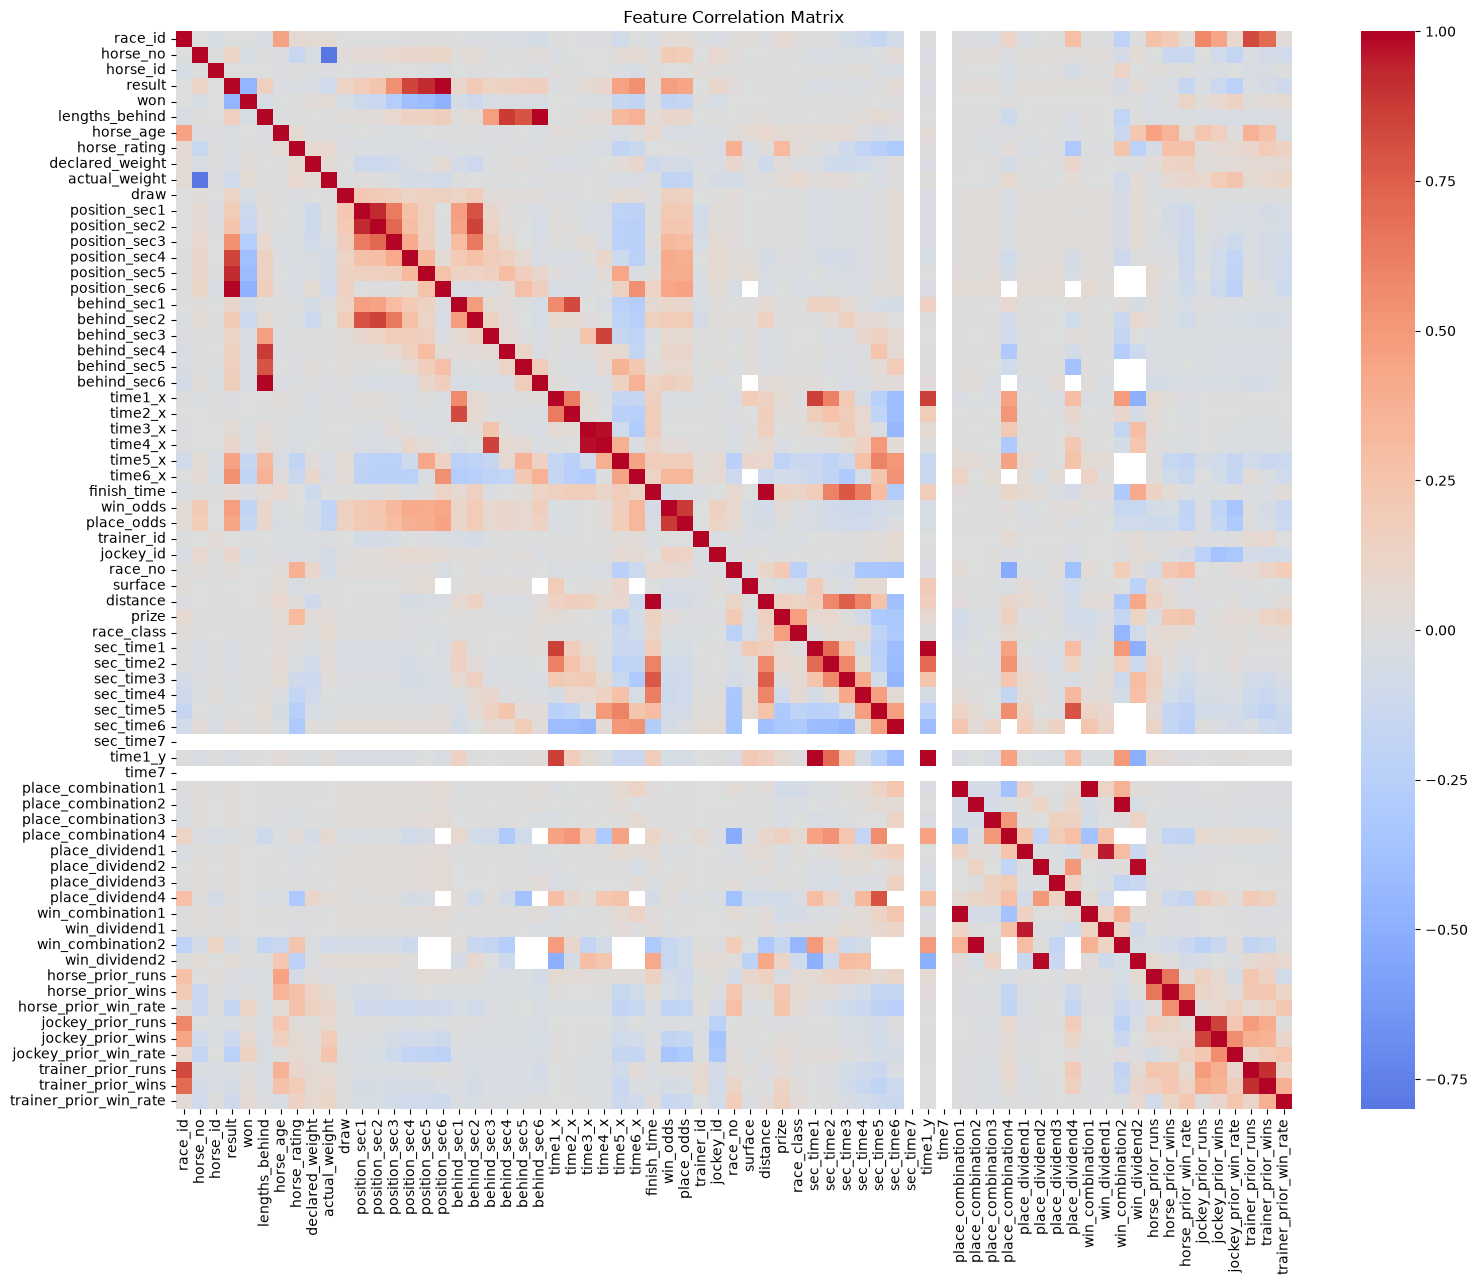

In [27]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [28]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df["horse_rating"],
    df["actual_weight"]
)

print("r =", r)
print("p =", p)

r = 0.07851544134481162
p = 7.559610985963341e-109


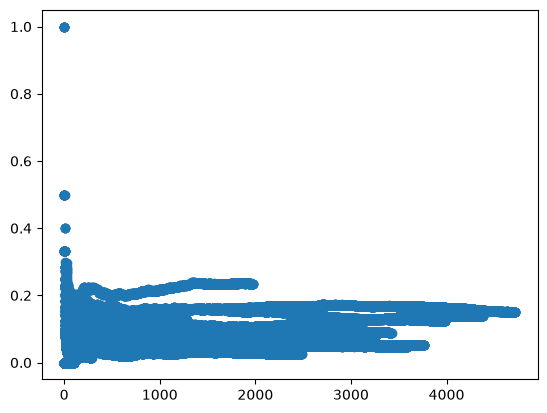

In [29]:
plt.scatter(df['jockey_prior_runs'], df['jockey_prior_win_rate'])

In [30]:
def plot_win_percentage(df, col, target="won"):
    """
    Plot win percentage by a categorical or discrete feature.
    """

    win_pct = (df.groupby(col)[target].mean().mul(100).reset_index(name="win_pct"))

    plt.figure(figsize=(8, 6), dpi=100)

    sns.lineplot(
        data=win_pct,
        x=col,
        y="win_pct",
        marker="o"
    )

    plt.xlabel(col, fontsize=14)
    plt.ylabel("Win percentage", fontsize=14)
    plt.title(f"{col} vs Win Percentage")
    plt.tight_layout()
    plt.show()

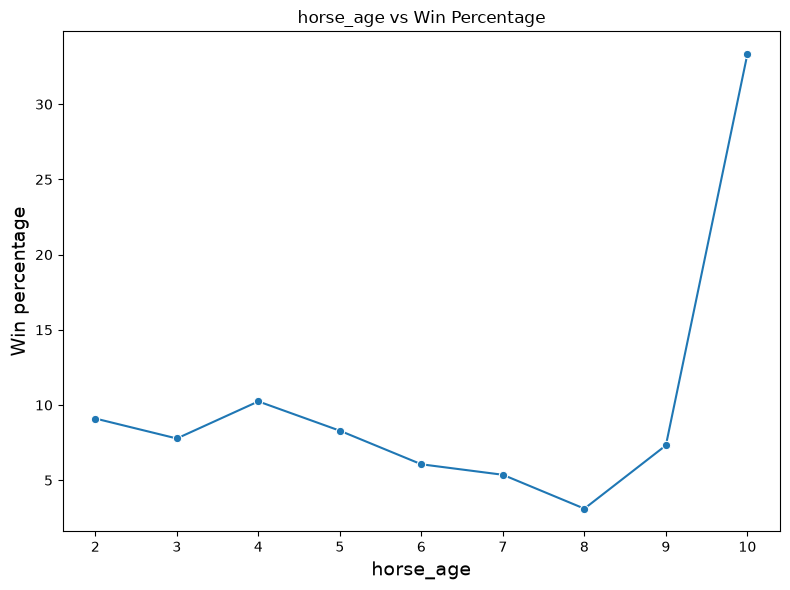

In [31]:
plot_win_percentage(df, "horse_age")

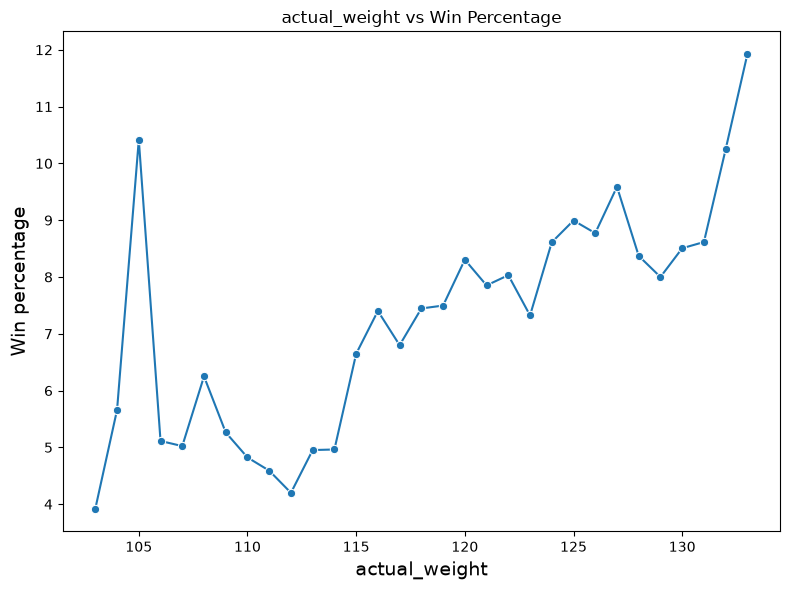

In [32]:
plot_win_percentage(df, "actual_weight")

In [33]:
df.columns.tolist()

['race_id',
 'horse_no',
 'horse_id',
 'result',
 'won',
 'lengths_behind',
 'horse_age',
 'horse_country',
 'horse_type',
 'horse_rating',
 'horse_gear',
 'declared_weight',
 'actual_weight',
 'draw',
 'position_sec1',
 'position_sec2',
 'position_sec3',
 'position_sec4',
 'position_sec5',
 'position_sec6',
 'behind_sec1',
 'behind_sec2',
 'behind_sec3',
 'behind_sec4',
 'behind_sec5',
 'behind_sec6',
 'time1_x',
 'time2_x',
 'time3_x',
 'time4_x',
 'time5_x',
 'time6_x',
 'finish_time',
 'win_odds',
 'place_odds',
 'trainer_id',
 'jockey_id',
 'date',
 'venue',
 'race_no',
 'config',
 'surface',
 'distance',
 'going',
 'horse_ratings',
 'prize',
 'race_class',
 'sec_time1',
 'sec_time2',
 'sec_time3',
 'sec_time4',
 'sec_time5',
 'sec_time6',
 'sec_time7',
 'time1_y',
 'time7',
 'place_combination1',
 'place_combination2',
 'place_combination3',
 'place_combination4',
 'place_dividend1',
 'place_dividend2',
 'place_dividend3',
 'place_dividend4',
 'win_combination1',
 'win_dividend1'

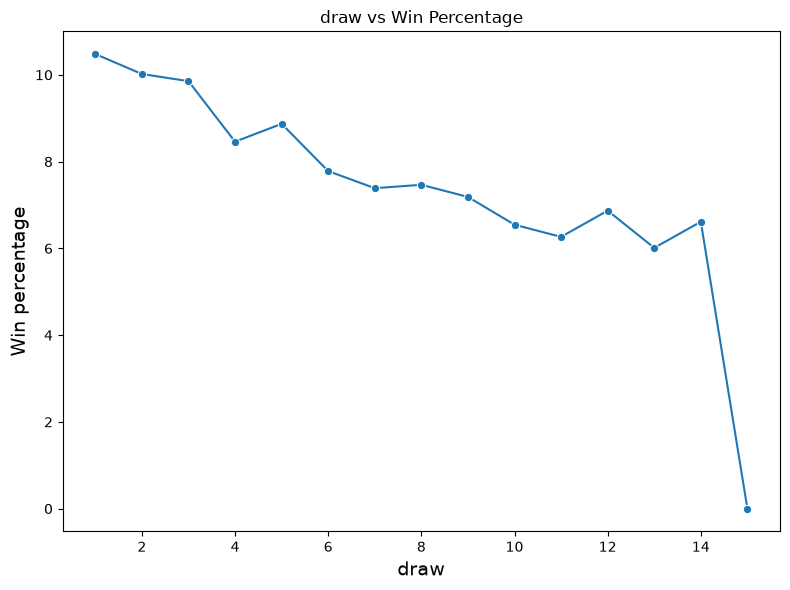

In [34]:
plot_win_percentage(df, 'draw')

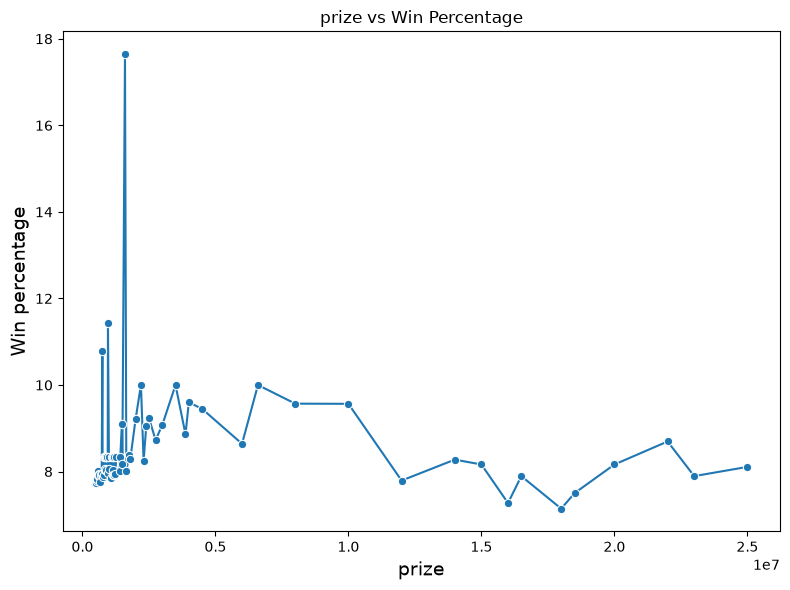

In [35]:
plot_win_percentage(df, 'prize')

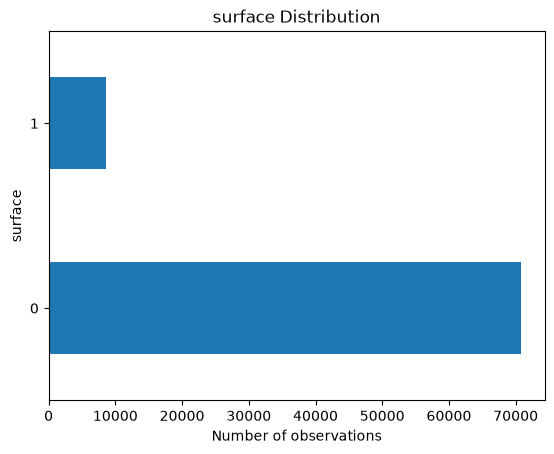

In [36]:
def plot_distr(df, col):
    df[col].value_counts().plot(kind = 'barh')

    plt.xlabel("Number of observations")
    plt.ylabel(col)
    plt.title(f"{col} Distribution")
    plt.show()

plot_distr(df, 'surface')

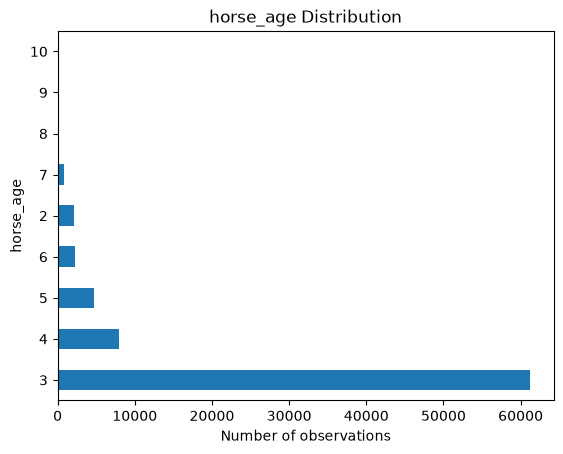

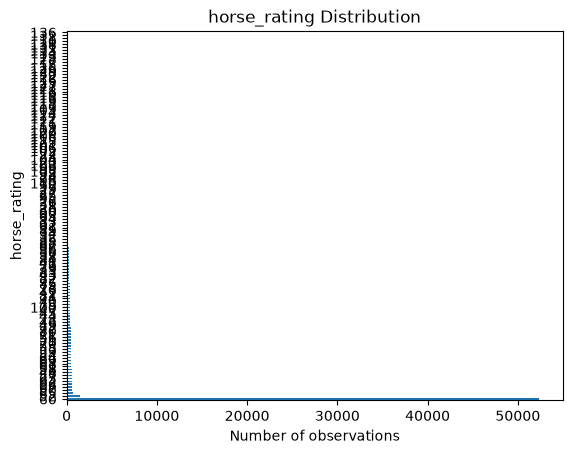

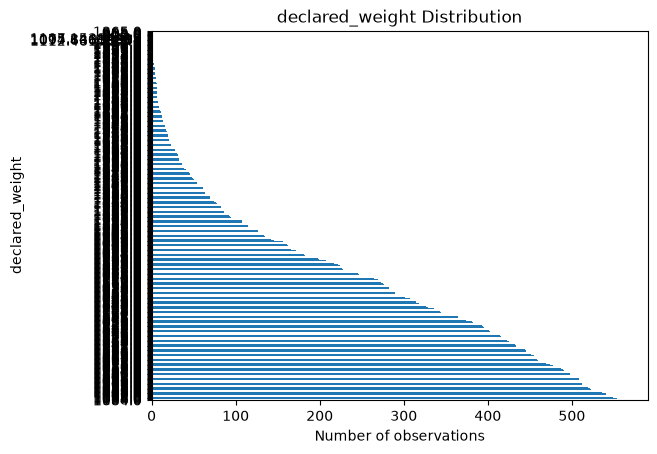

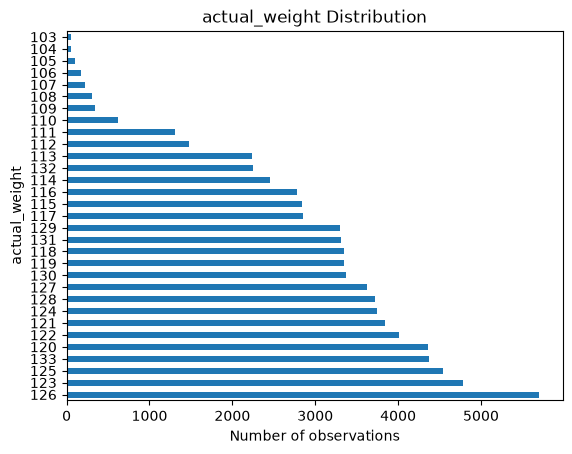

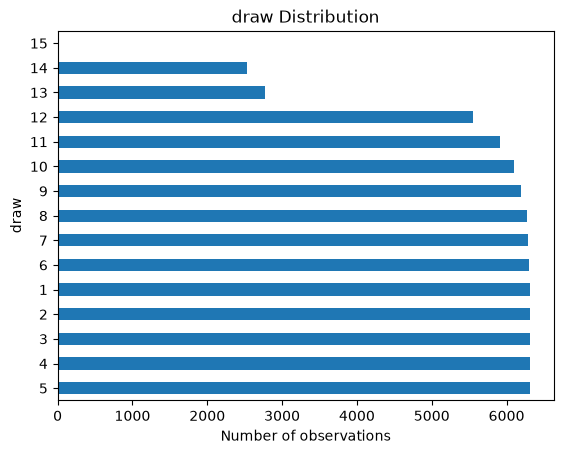

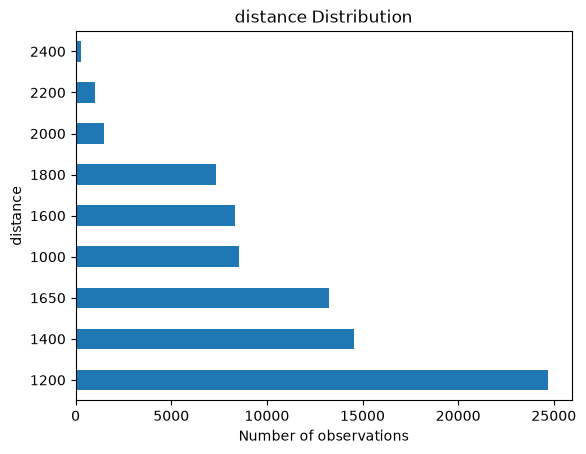

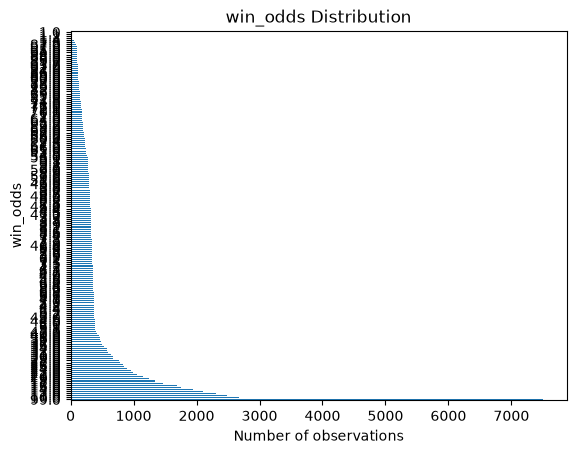

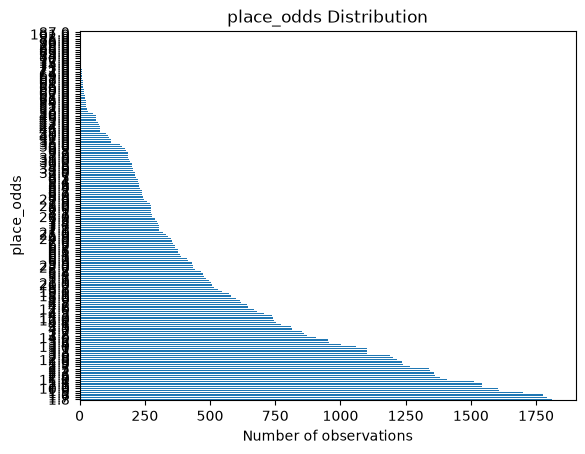

In [37]:
for col in initial_features:
    plot_distr(df, col)

In [38]:
df['horse_type'].value_counts()

horse_type
Gelding    75503
Brown       2044
Horse       1093
Colt         305
Mare         238
Rig          154
Roan          48
Filly         43
Grey          17
Name: count, dtype: int64

In [39]:
df['horse_sex'] = df['horse_type'].transform(lambda x: 'Male' if x in ['Gelding', 'Colt', 'Mare']
                                             else 'Female' if x in ['Mare', 'Rig', 'Roan', 'Filly']
                                             else 'Unknown')

In [40]:
df.head(10)

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,horse_prior_runs,horse_prior_wins,horse_prior_win_rate,jockey_prior_runs,jockey_prior_wins,jockey_prior_win_rate,trainer_prior_runs,trainer_prior_wins,trainer_prior_win_rate,horse_sex
0,0,1,3917,10,0.0,8.00,3,AUS,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
1,0,2,2157,8,0.0,5.75,3,NZ,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
2,0,3,858,7,0.0,4.75,3,NZ,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
3,0,4,1853,9,0.0,6.25,3,SAF,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
4,0,5,2796,6,0.0,3.75,3,GB,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
5,0,6,3296,3,0.0,1.25,3,NZ,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
6,0,7,911,12,0.0,9.50,3,NZ,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
7,0,8,2170,1,1.0,0.00,3,AUS,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
8,0,9,1730,13,0.0,9.75,3,NZ,Gelding,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male
9,0,10,2998,14,0.0,999.00,3,AUS,Mare,60,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,Male


In [41]:
df.sort_values(['date', 'horse_id'])

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,horse_prior_runs,horse_prior_wins,horse_prior_win_rate,jockey_prior_runs,jockey_prior_wins,jockey_prior_win_rate,trainer_prior_runs,trainer_prior_wins,trainer_prior_win_rate,horse_sex
54,4,1,82,3,0.0,0.50,3,NZ,Gelding,60,...,0,NaN,NaN,4,0.0,0.000000,3,0.0,0.000000,Male
55,4,2,97,1,1.0,0.00,3,AUS,Gelding,60,...,0,NaN,NaN,2,0.0,0.000000,2,0.0,0.000000,Male
34,2,7,133,11,0.0,4.25,3,NZ,Gelding,60,...,0,NaN,NaN,1,0.0,0.000000,2,0.0,0.000000,Male
59,4,6,134,12,0.0,8.25,3,AUS,Gelding,60,...,0,NaN,NaN,4,0.0,0.000000,2,0.0,0.000000,Male
61,4,8,243,7,0.0,4.50,3,NZ,Brown,60,...,0,NaN,NaN,3,0.0,0.000000,2,0.0,0.000000,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79351,6341,10,4266,12,0.0,7.00,4,NZ,Gelding,65,...,13,3.0,0.230769,52,0.0,0.000000,3580,260.0,0.072626,Male
79409,6346,3,4300,8,0.0,5.50,6,IRE,Gelding,128,...,25,10.0,0.400000,1972,463.0,0.234787,4105,503.0,0.122533,Male
79428,6347,10,4355,12,0.0,9.25,4,AUS,Gelding,85,...,8,1.0,0.125000,53,0.0,0.000000,1245,105.0,0.084337,Male
79389,6344,7,4362,2,0.0,0.15,3,AUS,Gelding,104,...,6,2.0,0.333333,4376,606.0,0.138483,4101,503.0,0.122653,Male


In [125]:
# data splitting w/o leakage

split_date = df["date"].quantile(0.8)

train = df[df["date"] < split_date]
test = df[df["date"] >= split_date]



In [82]:
print(df["date"].quantile(0.8))

2003-12-28 00:00:00


## Pipeline fit ##

1. Logistic regression baseline


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
# define features


numeric_features = [
 'horse_age',
 'declared_weight',
 'actual_weight',
 'draw',
 'win_odds',
 'place_odds',
 'race_no',
 'distance',
 'prize',
 'horse_prior_runs',
 'horse_prior_win_rate',
 'jockey_prior_runs',
 'jockey_prior_win_rate',
 'trainer_prior_runs',
 'trainer_prior_win_rate']

categorical_features = [
    "venue",
    "surface",
    "going",
    "horse_sex",
    "horse_country",
    'horse_gear',
    'config',
    'race_class',  
]

target = 'won'

In [67]:
df['horse_gear'].value_counts()

horse_gear
--              57373
B                3579
TT               2973
TT/B             2733
H                1360
                ...  
TT1/P1              1
CP-/P2              1
TT/XB/V2            1
TT1/XB-/H/B1        1
V-/XB1/B2/H2        1
Name: count, Length: 822, dtype: int64

In [70]:
# pre-processing the horse gear

gear_cat = set()

for gear in df['horse_gear']:
    for smaller in gear.split('/'):
        gear_cat.add(smaller)




In [71]:
gear_cat

{'--',
 'B',
 'B-',
 'B1',
 'B2',
 'BO',
 'BO-',
 'BO1',
 'BO2',
 'CO',
 'CO-',
 'CO1',
 'CP',
 'CP-',
 'CP1',
 'CP2',
 'E',
 'E-',
 'E1',
 'H',
 'H-',
 'H1',
 'H2',
 'P',
 'P-',
 'P1',
 'P2',
 'PC',
 'PC-',
 'PC1',
 'PC2',
 'SB',
 'SB-',
 'SB1',
 'SR',
 'SR-',
 'SR1',
 'SR2',
 'TT',
 'TT-',
 'TT1',
 'TT2',
 'V',
 'V-',
 'V1',
 'V2',
 'XB',
 'XB-',
 'XB1',
 'XB2'}

In [72]:
gear_counts = df["horse_gear"].str.split("/").str.len()

gear_counts.max()

5

In [73]:
gear_split = df["horse_gear"].fillna("").str.split("/")

for i in range(5):
    df[f"gear_{i+1}"] = gear_split.str[i]

In [76]:
df.drop(
    ["gear_1", "gear_2", "gear_3", "gear_4", "gear_5"]
, axis = 1, inplace = True)

In [77]:
gear_dummies = df["horse_gear"].fillna("").str.get_dummies(sep="/")

In [78]:
gear_dummies.head()

,--,B,B-,B1,B2,BO,BO-,BO1,BO2,CO,...,TT1,TT2,V,V-,V1,V2,XB,XB-,XB1,XB2
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
df = pd.concat([df, gear_dummies], axis=1)

In [88]:
categorical_features.extend(gear_dummies.columns.to_list())

In [89]:
categorical_features

['venue',
 'surface',
 'going',
 'horse_sex',
 'horse_country',
 'horse_gear',
 'config',
 'race_class',
 '--',
 'B',
 'B-',
 'B1',
 'B2',
 'BO',
 'BO-',
 'BO1',
 'BO2',
 'CO',
 'CO-',
 'CO1',
 'CP',
 'CP-',
 'CP1',
 'CP2',
 'E',
 'E-',
 'E1',
 'H',
 'H-',
 'H1',
 'H2',
 'P',
 'P-',
 'P1',
 'P2',
 'PC',
 'PC-',
 'PC1',
 'PC2',
 'SB',
 'SB-',
 'SB1',
 'SR',
 'SR-',
 'SR1',
 'SR2',
 'TT',
 'TT-',
 'TT1',
 'TT2',
 'V',
 'V-',
 'V1',
 'V2',
 'XB',
 'XB-',
 'XB1',
 'XB2']

In [90]:
# define pre-processing for numerical variables

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [91]:
# define pre-processing for categorical variables

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [92]:
# combine them
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [93]:
# model

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

In [94]:
X_train = train[categorical_features + numeric_features]

In [95]:
X_test = test[categorical_features + numeric_features]

In [96]:
y_train = train[target]

In [97]:
y_test = test[target]

In [98]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['horse_age',
                                                   'declared_weight',
                                                   'actual_weight', 'draw',
                                                   'win_odds', 'place_odds',
                                                   'race_no', 'distance',
                                                   'prize', 'horse_prior_runs',
                                                   'horse_prior_win_rate',
                                                   'jockey_prior_runs',
                                                   'jockey_prior_win_r...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['venue', 'surface', 'going',
                                                   'horse_sex', 'horse_country',
                                                   'horse_gear', 'config',
                                                   'race_class', '--', 'B',
                                                   'B-', 'B1', 'B2', 'BO',
                                                   'BO-', 'BO1', 'BO2', 'CO',
                                                   'CO-', 'CO1', 'CP', 'CP-',
                                                   'CP1', 'CP2', 'E', 'E-',
                                                   'E1', 'H', 'H-', 'H1', ...])])),
                ('classifier', LogisticRegression(max_iter=2000))])

In [99]:
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [172]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df.head(30)

,feature,coefficient
197,cat__horse_gear_H/SR/XB,1.403159
349,cat__horse_gear_TT/B/H,1.048096
279,cat__horse_gear_TT-/B,1.006267
362,cat__horse_gear_TT/CP,0.886227
330,cat__horse_gear_TT/B-/H,0.882832
570,cat__horse_gear_XB-/H,0.875731
259,cat__horse_gear_SR-/CP1,0.871292
470,cat__horse_gear_TT/XB,0.857233
357,cat__horse_gear_TT/B1,0.771380
326,cat__horse_gear_TT/B,0.755069


In [173]:
coef_df.tail(30)

,feature,coefficient
620,cat__BO1_1,-0.366520
508,cat__horse_gear_TT1/H,-0.366536
86,cat__horse_gear_B/H/XB,-0.368302
573,cat__horse_gear_XB-/SR1,-0.370335
410,cat__horse_gear_TT/H/CP,-0.377817
487,cat__horse_gear_TT1/B-,-0.380972
272,cat__horse_gear_SR/H1,-0.391684
383,cat__horse_gear_TT/CP1,-0.394359
703,cat__XB2_1,-0.403576
562,cat__horse_gear_V/XB,-0.413059


In [100]:
from sklearn.metrics import log_loss, brier_score_loss

print("Log loss:", log_loss(y_test, y_pred_prob))
print("Brier score:", brier_score_loss(y_test, y_pred_prob))

Log loss: 0.24571125632277319
Brier score: 0.0683262828539889


In [101]:
print("(basic) Accuracy as a sanity check:", model.score(X_test, y_test))

(basic) Accuracy as a sanity check: 0.9198675910311661


In [103]:
# 2. XGBoost

import xgboost as xgb
from xgboost import XGBClassifier

In [104]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [105]:
model_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [107]:
model_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['horse_age',
                                                   'declared_weight',
                                                   'actual_weight', 'draw',
                                                   'win_odds', 'place_odds',
                                                   'race_no', 'distance',
                                                   'prize', 'horse_prior_runs',
                                                   'horse_prior_win_rate',
                                                   'jockey_prior_runs',
                                                   'jockey_prior_win_r...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [113]:
y_pred_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [114]:
print("Log loss:", log_loss(y_test, y_pred_prob_xgb))
print("Brier score:", brier_score_loss(y_test, y_pred_prob_xgb))

Log loss: 0.24736979065929016
Brier score: 0.069003866873783


Check calibrations of both

In [115]:
from sklearn.calibration import calibration_curve

In [117]:
# first obtain the current market probabilities

In [118]:
df["market_raw_prob"] = 1 / df["win_odds"]

In [121]:
#normalise PER RACE
df["market_prob"] = (
    df["market_raw_prob"]
    / df.groupby("race_id")["market_raw_prob"].transform("sum")
)

In [127]:
market_prob = test["market_prob"].values

In [128]:
market_logloss = log_loss(y_test, market_prob)
market_brier = brier_score_loss(y_test, market_prob)

print("Market log loss:", market_logloss)
print("Market Brier:", market_brier)

Market log loss: 0.23587998739930113
Market Brier: 0.06601295845920468


In [135]:

lr_true, lr_pred = calibration_curve(
    y_test,
    y_pred_prob,
    n_bins=10,
    #strategy="quantile"
)

xgb_true, xgb_pred = calibration_curve(
    y_test,
    y_pred_prob_xgb,
    n_bins=10,
    #strategy="quantile"
)

market_true, market_pred = calibration_curve(
    y_test,
    test["market_prob"],
    n_bins=10,
    #strategy="quantile"
)

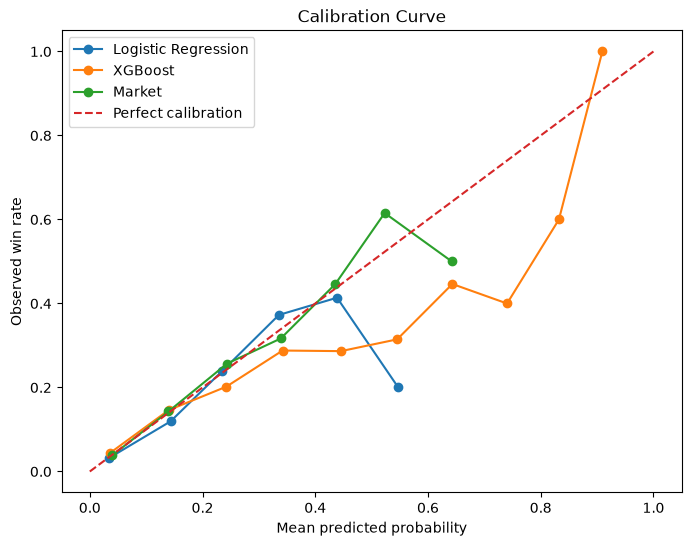

In [136]:
plt.figure(figsize=(8, 6))

plt.plot(lr_pred, lr_true, marker="o", label="Logistic Regression")
plt.plot(xgb_pred, xgb_true, marker="o", label="XGBoost")
plt.plot(market_pred, market_true, marker="o", label="Market")

plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed win rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [137]:
df.groupby("race_id")["market_prob"].sum().head()

race_id
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: market_prob, dtype: float64

In [138]:
test["model_prob_xgb"] = y_pred_prob_xgb

In [139]:
test["edge_xgb"] = test["model_prob_xgb"] - test["market_prob"]

In [140]:
# expected value, i.e. how much we win/ lose when we bet $1
test["ev_xgb"] = test["model_prob_xgb"] * test["win_odds"] - 1

In [141]:
test["ev_xgb"].describe()

count    16011.000000
mean        -0.192137
std          0.624756
min         -0.989223
25%         -0.555767
50%         -0.295928
75%         -0.004299
max         13.746078
Name: ev_xgb, dtype: float64

In [142]:
test.sort_values("ev_xgb", ascending=False)[
    ["race_id", "horse_id", "win_odds",
     "model_prob_xgb", "market_prob", "edge_xgb",
     "ev_xgb", "won"]
].head(20)

,race_id,horse_id,win_odds,model_prob_xgb,market_prob,edge_xgb,ev_xgb,won
77031,6155,648,61.0,0.241739,0.013393,0.228346,13.746078,0.0
77541,6196,3131,65.0,0.171297,0.012400,0.158897,10.134323,0.0
77869,6222,1279,52.0,0.209231,0.015663,0.193568,9.880012,0.0
67412,5388,1253,66.0,0.137514,0.012175,0.125339,8.075897,1.0
79219,6330,1796,43.0,0.209122,0.018709,0.190414,7.992267,0.0
76336,6099,1972,67.0,0.131284,0.011999,0.119285,7.796036,1.0
76944,6147,1330,46.0,0.190353,0.017795,0.172558,7.756222,0.0
77391,6184,1471,53.0,0.164109,0.015316,0.148793,7.697798,0.0
76992,6151,2584,52.0,0.161325,0.015609,0.145716,7.388908,0.0
67125,5365,2265,53.0,0.154408,0.015358,0.139051,7.183636,0.0


In [143]:
# betting strategy

bets = test[test["ev_xgb"] > 0]

In [144]:
test["profit"] = np.where(
    test["won"] == 1,
    test["win_odds"] - 1,
    -1
)

In [145]:
bets = test[test["ev_xgb"] > 0]

total_profit = bets["profit"].sum()
total_staked = len(bets)

roi = total_profit / total_staked

print("Bets:", len(bets))
print("Profit:", total_profit)
print("ROI:", roi)

Bets: 3965
Profit: -803.0
ROI: -0.2025220680958386


In [146]:
thresholds = [0, 0.05, 0.10, 0.20, 0.50]

for threshold in thresholds:
    bets = test[test["ev_xgb"] > threshold]

    profit = bets["profit"].sum()
    staked = len(bets)

    roi = profit / staked if staked > 0 else np.nan

    print(
        f"EV > {threshold:.0%}: "
        f"{len(bets)} bets, "
        f"profit = {profit:.2f}, "
        f"ROI = {roi:.2%}"
    )

EV > 0%: 3965 bets, profit = -803.00, ROI = -20.25%
EV > 5%: 3527 bets, profit = -697.90, ROI = -19.79%
EV > 10%: 3123 bets, profit = -553.90, ROI = -17.74%
EV > 20%: 2510 bets, profit = -464.90, ROI = -18.52%
EV > 50%: 1346 bets, profit = -206.70, ROI = -15.36%


In [149]:
# try calibrated xgb

from sklearn.calibration import CalibratedClassifierCV

xgb_calibrated = CalibratedClassifierCV(
    model_xgb,
    method="sigmoid",
    cv=5
)

xgb_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['horse_age',
                                                                                    'declared_weight',
                                                                                    'actual_weight',
                                                                                    'draw',
                                                                                    'win_odds',
                                                                                    'place_odds',
                                                                                    'race_no',
                                                                                    'distance',
                                                                                    'prize',
                                                                                    'horse_prior_runs',
                                                                                    'horse_prior_win_rate',
                                                                                    '...
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=500,
                                                                n_jobs=None,
                                                                num_parallel_tree=None,
                                                                random_state=42, ...))]))

In [150]:
xgb_cal_prob = xgb_calibrated.predict_proba(X_test)[:, 1]

In [151]:
print("Uncalibrated XGB")
print("Log loss:", log_loss(y_test, y_pred_prob_xgb))
print("Brier:", brier_score_loss(y_test, y_pred_prob_xgb))

print("\nCalibrated XGB")
print("Log loss:", log_loss(y_test, xgb_cal_prob))
print("Brier:", brier_score_loss(y_test, xgb_cal_prob))

Uncalibrated XGB
Log loss: 0.24736979065929016
Brier: 0.069003866873783

Calibrated XGB
Log loss: 0.251292670677005
Brier: 0.06895001241772368


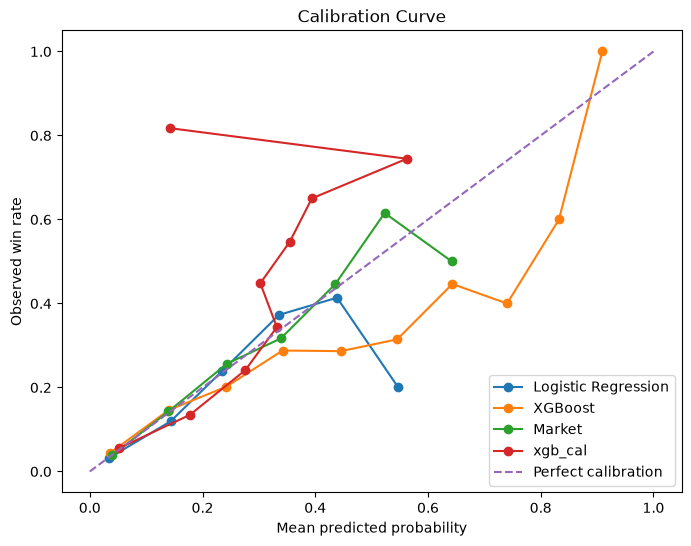

In [ ]:

lr_true, lr_pred = calibration_curve(
    y_test,
    y_pred_prob,
    n_bins=10,
    #strategy="quantile"
)

xgb_true, xgb_pred = calibration_curve(
    y_test,
    y_pred_prob_xgb,
    n_bins=10,
    #strategy="quantile"
)

market_true, market_pred = calibration_curve(
    y_test,
    test["market_prob"],
    n_bins=10,
    #strategy="quantile"
)

xgb_cal_true, xgb_cal_pred = calibration_curve(
    y_test,
    xgb_cal_prob,
    n_bins=10,
    #strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(lr_pred, lr_true, marker="o", label="Logistic Regression")
plt.plot(xgb_pred, xgb_true, marker="o", label="XGBoost")
plt.plot(market_pred, market_true, marker="o", label="Market")
plt.plot(xgb_cal_true, xgb_cal_pred, marker="o", label="xgb_cal")


plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed win rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [153]:
# try grid search for hyperparameters

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42
    ))
])

param_grid = {
    "model__n_estimators": [200, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 6],
    "model__min_child_weight": [1, 5],
}

In [156]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="neg_log_loss", # minimises log loss = cross-entropy
    cv=tscv, # need time series split!!!
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['horse_age',
                                                                          'declared_weight',
                                                                          'actual_weight',
                                                                          'draw',
                                                                          'win_odds',
                                                                          'place_odds',
                                                                          'race_no',
                                                                          'dist...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [3, 6],
                         'model__min_child_weight': [1, 5],
                         'model__n_estimators': [200, 500]},
             scoring='neg_log_loss', verbose=1)

In [157]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 200}
-0.23714973679985935


In [158]:
best_xgb = grid_search.best_estimator_

In [159]:
y_pred_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [160]:
print("\nCalibrated XGB from grid search")
print("Log loss:", log_loss(y_test, y_pred_prob_xgb))
print("Brier:", brier_score_loss(y_test, y_pred_prob_xgb))


Calibrated XGB from grid search
Log loss: 0.2359072174316363
Brier: 0.06605646508157811


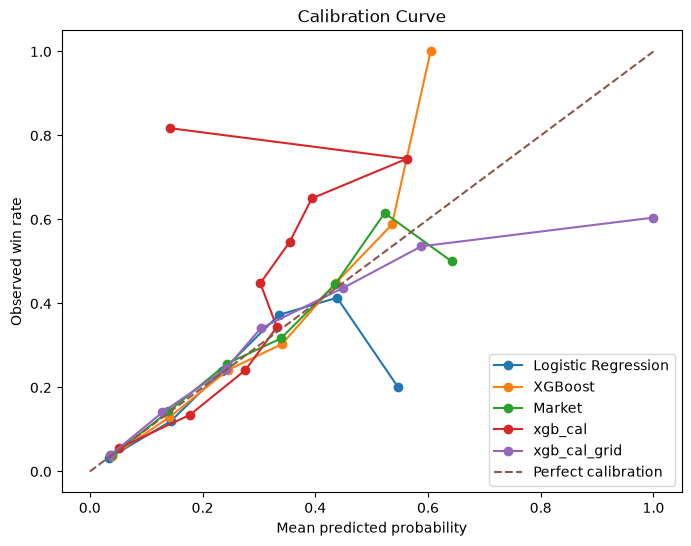

In [161]:

lr_true, lr_pred = calibration_curve(
    y_test,
    y_pred_prob,
    n_bins=10,
    #strategy="quantile"
)

xgb_true, xgb_pred = calibration_curve(
    y_test,
    y_pred_prob_xgb,
    n_bins=10,
    #strategy="quantile"
)

market_true, market_pred = calibration_curve(
    y_test,
    test["market_prob"],
    n_bins=10,
    #strategy="quantile"
)

xgb_cal_true, xgb_cal_pred = calibration_curve(
    y_test,
    xgb_cal_prob,
    n_bins=10,
    #strategy="quantile"
)

xgb_grid_cal_true, xgb_grid_cal_pred = calibration_curve(
    y_test,
    y_pred_prob_xgb,
    n_bins=10,
    #strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(lr_pred, lr_true, marker="o", label="Logistic Regression")
plt.plot(xgb_pred, xgb_true, marker="o", label="XGBoost")
plt.plot(market_pred, market_true, marker="o", label="Market")
plt.plot(xgb_cal_true, xgb_cal_pred, marker="o", label="xgb_cal")
plt.plot(xgb_grid_cal_true, xgb_grid_cal_pred, marker="o", label="xgb_cal_grid")

plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed win rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [162]:
# Add XGBoost predicted probabilities
test["model_prob_xgb"] = y_pred_prob_xgb

# Expected value per £1 staked
test["ev_xgb"] = (
    test["model_prob_xgb"] * test["win_odds"] - 1
)

# Actual profit from a £1 bet
test["profit"] = np.where(
    test["won"] == 1,
    test["win_odds"] - 1,
    -1
)

In [163]:
thresholds = [0, 0.05, 0.10, 0.20, 0.50]

for threshold in thresholds:

    bets = test[test["ev_xgb"] > threshold]

    profit = bets["profit"].sum()
    staked = len(bets)

    roi = profit / staked if staked > 0 else np.nan

    print(
        f"EV > {threshold:.0%}: "
        f"{len(bets)} bets, "
        f"profit = {profit:.2f}, "
        f"ROI = {roi:.2%}"
    )

EV > 0%: 2426 bets, profit = -513.20, ROI = -21.15%
EV > 5%: 1558 bets, profit = -391.60, ROI = -25.13%
EV > 10%: 1051 bets, profit = -225.70, ROI = -21.47%
EV > 20%: 523 bets, profit = -139.00, ROI = -26.58%
EV > 50%: 57 bets, profit = 10.00, ROI = 17.54%


In [164]:
test.sort_values("ev_xgb", ascending=False)[
    [
        "race_id",
        "horse_id",
        "win_odds",
        "model_prob_xgb",
        "market_prob",
        "ev_xgb",
        "won"
    ]
].head(20)

,race_id,horse_id,win_odds,model_prob_xgb,market_prob,ev_xgb,won
78126,6244,2278,99.0,0.022111,0.008233,1.188962,0.0
77254,6173,2278,99.0,0.022106,0.008238,1.188473,0.0
79061,6318,227,99.0,0.021519,0.008198,1.130351,0.0
78485,6272,601,99.0,0.020942,0.008197,1.073278,0.0
78971,6311,1723,99.0,0.020805,0.008183,1.059742,0.0
77575,6199,227,99.0,0.020788,0.008253,1.058031,0.0
78096,6242,1887,99.0,0.020450,0.008263,1.024541,0.0
77031,6155,648,61.0,0.032340,0.013393,0.972719,0.0
78136,6245,227,99.0,0.019597,0.008129,0.940119,0.0
79108,6322,3772,99.0,0.019573,0.008236,0.937764,0.0


In [165]:
test[["win_odds", "model_prob_xgb", "ev_xgb"]].describe()

,win_odds,model_prob_xgb,ev_xgb
count,16011.000000,16011.000000,16011.000000
mean,30.063169,0.084827,-0.163994
std,31.483205,0.088831,0.210561
min,1.200000,0.001974,-0.804570
25%,7.800000,0.020567,-0.240148
50%,15.000000,0.054787,-0.145536
75%,40.000000,0.115638,-0.057524
max,99.000000,0.608963,1.188962


In [166]:
test["odds_bin"] = pd.cut(
    test["win_odds"],
    bins=[0, 2, 5, 10, 20, 50, 100],
    include_lowest=True
)

test.groupby("odds_bin").agg(
    n=("won", "size"),
    model_prob=("model_prob_xgb", "mean"),
    actual_win_rate=("won", "mean"),
    mean_odds=("win_odds", "mean"),
    mean_ev=("ev_xgb", "mean")
)

,n,model_prob,actual_win_rate,mean_odds,mean_ev
odds_bin,,,,,
"(-0.001, 2.0]",179,0.447035,0.474860,1.774302,-0.212652
"(2.0, 5.0]",1972,0.252736,0.241379,3.628296,-0.126282
"(5.0, 10.0]",3658,0.119631,0.109349,7.760197,-0.115438
"(10.0, 20.0]",3612,0.059830,0.056202,14.754153,-0.144493
"(20.0, 50.0]",3229,0.029686,0.029111,32.163518,-0.112174
"(50.0, 100.0]",3361,0.008977,0.006546,85.788158,-0.307117


In [167]:
test["prob_diff"] = (
    test["model_prob_xgb"] - test["market_prob"]
)

test["ev_xgb"] = (
    test["model_prob_xgb"] * test["win_odds"] - 1
)

In [168]:
test[[
    "model_prob_xgb",
    "market_prob",
    "prob_diff",
    "ev_xgb"
]].describe()

,model_prob_xgb,market_prob,prob_diff,ev_xgb
count,16011.000000,16011.000000,16011.000000,16011.000000
mean,0.084827,0.079820,0.005007,-0.163994
std,0.088831,0.084931,0.013541,0.210561
min,0.001974,0.007920,-0.137197,-0.804570
25%,0.020567,0.020077,-0.002473,-0.240148
50%,0.054787,0.053257,0.002717,-0.145536
75%,0.115638,0.104375,0.009696,-0.057524
max,0.608963,0.673173,0.116507,1.188962


In [169]:
test["prob_diff_bin"] = pd.qcut(
    test["prob_diff"],
    q=10,
    duplicates="drop"
)

test.groupby("prob_diff_bin", observed=True).agg(
    n=("won", "size"),
    model_prob=("model_prob_xgb", "mean"),
    market_prob=("market_prob", "mean"),
    actual_win_rate=("won", "mean"),
    mean_ev=("ev_xgb", "mean"),
    roi=("profit", "mean")
)

,n,model_prob,market_prob,actual_win_rate,mean_ev,roi
prob_diff_bin,,,,,,
"(-0.138, -0.0058]",1602,0.118735,0.131918,0.123596,-0.351913,-0.360487
"(-0.0058, -0.00355]",1601,0.032581,0.037366,0.025609,-0.492073,-0.574453
"(-0.00355, -0.00157]",1601,0.034732,0.037244,0.028732,-0.319536,-0.443598
"(-0.00157, 0.000582]",1601,0.047781,0.048312,0.054966,-0.211651,-0.087758
"(0.000582, 0.00272]",1601,0.053192,0.051523,0.053092,-0.131392,-0.179013
"(0.00272, 0.005]",1601,0.060059,0.056228,0.050593,-0.062870,-0.227046
"(0.005, 0.00792]",1601,0.069954,0.063515,0.064335,-0.033054,-0.188007
"(0.00792, 0.0121]",1601,0.090761,0.080975,0.079325,-0.012539,-0.178951
"(0.0121, 0.0204]",1601,0.131067,0.115470,0.123673,-0.015863,-0.124610


Model	Why try it?	My priority
Logistic Regression	Strong linear baseline, often well calibrated	⭐⭐⭐⭐⭐
Random Forest	Captures nonlinear relationships/interactions	⭐⭐⭐⭐
XGBoost	Strong tabular-data model	⭐⭐⭐⭐⭐
LightGBM	Similar to XGB, often excellent on tabular data	⭐⭐⭐⭐⭐
HistGradientBoosting	sklearn-native gradient boosting	⭐⭐⭐⭐
Random Forest + calibration	RF probabilities can be poorly calibrated	⭐⭐⭐⭐
Extra Trees	More randomised tree ensemble; useful comparison	⭐⭐⭐
CatBoost	Excellent with categorical variables	⭐⭐⭐⭐⭐

In [175]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_xgb,
    X_test,
    y_test,
    scoring="neg_log_loss",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [179]:
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

In [181]:
importance_df.head(20)

,feature,importance
62,win_odds,0.072504
63,place_odds,0.005139
61,draw,0.001244
67,horse_prior_runs,0.000659
69,jockey_prior_runs,0.000565
66,prize,0.000335
10,B-,0.000316
5,horse_gear,0.000247
60,actual_weight,0.000234
55,XB-,0.000142


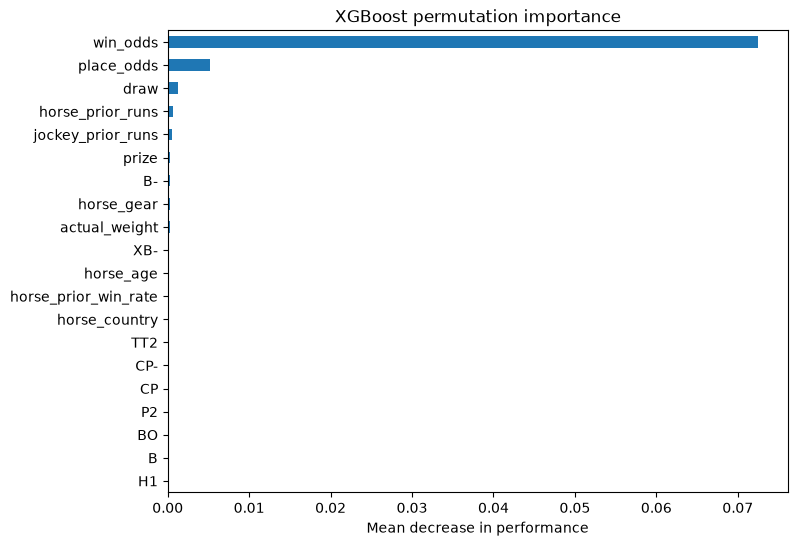

In [182]:
importance_df.head(20).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.xlabel("Mean decrease in performance")
plt.ylabel("")
plt.title("XGBoost permutation importance")
plt.show()

In [183]:
print(categorical_features)

['venue', 'surface', 'going', 'horse_sex', 'horse_country', 'horse_gear', 'config', 'race_class', '--', 'B', 'B-', 'B1', 'B2', 'BO', 'BO-', 'BO1', 'BO2', 'CO', 'CO-', 'CO1', 'CP', 'CP-', 'CP1', 'CP2', 'E', 'E-', 'E1', 'H', 'H-', 'H1', 'H2', 'P', 'P-', 'P1', 'P2', 'PC', 'PC-', 'PC1', 'PC2', 'SB', 'SB-', 'SB1', 'SR', 'SR-', 'SR1', 'SR2', 'TT', 'TT-', 'TT1', 'TT2', 'V', 'V-', 'V1', 'V2', 'XB', 'XB-', 'XB1', 'XB2']


In [185]:
X_test_transformed = model_xgb.named_steps[
    "preprocessor"
].transform(X_test)
X_test_transformed = X_test_transformed.toarray()
result = permutation_importance(
    model_xgb.named_steps["model"],
    X_test_transformed,
    y_test,
    scoring="neg_log_loss",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_names = model_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
}).sort_values(
    "importance",
    ascending=False
)

In [186]:
importance_df

,feature,importance
4,num__win_odds,0.051453
5,num__place_odds,0.004473
3,num__draw,0.002603
1,num__declared_weight,0.001990
12,num__jockey_prior_win_rate,0.000195
...,...,...
9,num__horse_prior_runs,-0.000442
8,num__prize,-0.000553
13,num__trainer_prior_runs,-0.001167
0,num__horse_age,-0.001303


In [ ]:
# can now try market independent, i.e. w/o num__win_odds